In [1]:
import numpy as np 
import torch, torchvision
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F 
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

In [2]:
torch.manual_seed(20)

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
    print('cuda available')
else:
    device = 'cpu'
    print('only cpu available')

cuda available


In [4]:
train_batch = 16
test_batch = 16

In [5]:
train_set = torchvision.datasets.MNIST(root='./data', download=True, train=True, transform=transforms.ToTensor())
test_set = torchvision.datasets.MNIST(root='./data', download=True, train=False, transform=transforms.ToTensor()) 

In [6]:
mean = train_set.data.float().mean()
std = train_set.data.float().std() 

In [7]:
tform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean / 255.0], std=[std/ 255.0])
])

In [8]:
train_set = torchvision.datasets.MNIST(root='./data', download=True, train=True, transform=tform)
test_set = torchvision.datasets.MNIST(root='./data', download=True, train=False, transform=tform)

In [9]:
train_loader = DataLoader(train_set, batch_size=train_batch, shuffle=True)
test_loader = DataLoader(test_set, batch_size=test_batch, shuffle=True) 

In [10]:
len(train_loader), len(test_loader)

(3750, 625)

In [11]:
example_data, example_label = next(iter(train_loader))

In [12]:
example_data.shape 

torch.Size([16, 1, 28, 28])

In [13]:
class VAE(nn.Module):
    def __init__(self, x_dim, hidden_dim, z_dim, bias=True):
        super().__init__() 
        self.encoding = nn.Linear(in_features=x_dim, out_features=hidden_dim, bias=bias)
        self.encoding_mu = nn.Linear(in_features=hidden_dim, out_features=z_dim, bias=bias)
        self.encoding_var = nn.Linear(in_features=hidden_dim, out_features=z_dim, bias=bias)

        self.decoding = nn.Linear(in_features = z_dim, out_features=hidden_dim, bias=bias)
        self.recon = nn.Linear(in_features=hidden_dim, out_features=x_dim, bias=bias)

    def encode(self, x):
        x = self.encoding(x)
        x = F.relu(x) 
        x_mu = self.encoding_mu(x) 
        x_mu = F.relu(x_mu)
        x_std = self.encoding_var(x) 
        x_std = F.relu(x_std) 
        return x_mu, x_std 

    def reparameterize(self, mu, logvar):
        # 2 ln var = x_std --> var = exp(x_std/2) 
        var = torch.exp(logvar / 2) 
        epsilon = torch.randn_like(var)
        return mu + epsilon * var 

    def decode(self, x):
        x = self.decoding(x)
        x = F.relu(x)
        x = self.recon(x)
        x = F.relu(x)
        return x 

    def forward(self, x):
        original_shape = x.shape 
        x_mu, x_std = self.encode(x.view(x.shape[0], -1))
        x = self.reparameterize(x_mu, x_std) 
        x = self.decode(x)
        return x.view(original_shape) 

In [14]:
model = VAE(28*28, 100, 50).to(device)
model 

VAE(
  (encoding): Linear(in_features=784, out_features=100, bias=True)
  (encoding_mu): Linear(in_features=100, out_features=50, bias=True)
  (encoding_var): Linear(in_features=100, out_features=50, bias=True)
  (decoding): Linear(in_features=50, out_features=100, bias=True)
  (recon): Linear(in_features=100, out_features=784, bias=True)
)

In [15]:
# before training, reconstruction should be noise 
example_data = example_data.to(device)
example_output = model(example_data)
example_output = example_output.cpu().detach() 
example_output.shape 

torch.Size([16, 1, 28, 28])

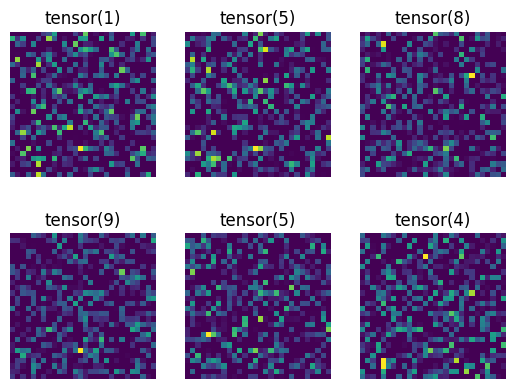

In [16]:
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_output[i].squeeze())
    plt.title(example_label[i])
    plt.axis('off')

In [17]:
train_loss = [] 
test_loss = [] 

In [18]:
learning_rate = 1e-3
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)
loss_fn = F.mse_loss 

In [22]:
def train():
    model.train()

    running_loss = 0 
    for data, label in train_loader:
        data, label = data.to(device), label.to(device)

        logits = model(data)
        loss = loss_fn(logits.view(logits.shape[0], -1), data.view(data.shape[0], -1))
        running_loss += loss.item() 

        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 

    train_loss.append(running_loss / len(train_set))

In [23]:
def test():
    model.eval() 

    running_loss = 0 
    with torch.no_grad():
        for data, label in test_loader:
            data, label = data.to(device), label.to(device)

            logits = model(data)
            loss = loss_fn(logits.view(logits.shape[0], -1), data.view(data.shape[0], -1))
            running_loss += loss.item() 

        test_loss.append(running_loss / len(test_set)) 

In [24]:
n_epochs = 100 
for i in range(n_epochs):
    train()
    test()
    if np.mod(i, 10) == 0:
        print(f'epoch {i}, train loss: {train_loss[-1]}, test loss: {test_loss[-1]}') 

epoch 0, train loss: 0.06408219841221968, test loss: 0.06447433992624282
epoch 10, train loss: 0.05006899941066901, test loss: 0.05008626503944397
epoch 20, train loss: 0.04707804271082083, test loss: 0.04690983186364174
epoch 30, train loss: 0.0417488206555446, test loss: 0.04141954345107079
epoch 40, train loss: 0.03771467163612445, test loss: 0.03734735788702965
epoch 50, train loss: 0.0354592141966025, test loss: 0.03516082608401775
epoch 60, train loss: 0.03402248611400525, test loss: 0.03371301035881043
epoch 70, train loss: 0.03281916521688302, test loss: 0.03255281127095223
epoch 80, train loss: 0.031987717681626476, test loss: 0.03171768279671669
epoch 90, train loss: 0.031149197693169116, test loss: 0.030892441269755364


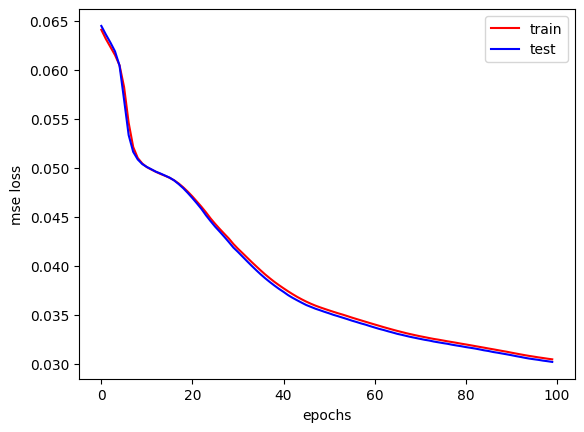

In [25]:
plt.figure()
plt.plot(train_loss, color='r', label='train')
plt.plot(test_loss, color='b', label='test')
plt.xlabel('epochs')
plt.ylabel('mse loss') 
plt.legend()

In [26]:
example_data = example_data.to(device)
example_output = model(example_data)
example_output = example_output.cpu().detach() 
example_output.shape 

torch.Size([16, 1, 28, 28])

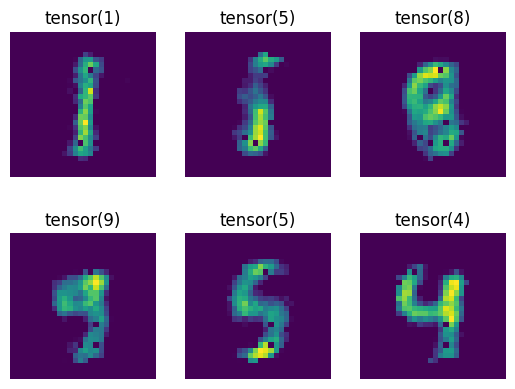

In [27]:
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_output[i].squeeze())
    plt.title(example_label[i])
    plt.axis('off')